In [29]:
# Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import joblib

import warnings
warnings.filterwarnings("ignore")

In [30]:
from google.colab import files
uploaded = files.upload()

Saving Unemployment_Rate_upto_11_2020.csv to Unemployment_Rate_upto_11_2020.csv


In [31]:
df = pd.read_csv("Unemployment_Rate_upto_11_2020.csv")

In [32]:
df.head()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Region.1,longitude,latitude
0,Andhra Pradesh,31-01-2020,M,5.48,16635535,41.02,South,15.9129,79.74
1,Andhra Pradesh,29-02-2020,M,5.83,16545652,40.90,South,15.9129,79.74
2,Andhra Pradesh,31-03-2020,M,5.79,15881197,39.18,South,15.9129,79.74
3,Andhra Pradesh,30-04-2020,M,20.51,11336911,33.10,South,15.9129,79.74
4,Andhra Pradesh,31-05-2020,M,17.43,12988845,36.46,South,15.9129,79.74


In [33]:
df.tail()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Region.1,longitude,latitude
262,West Bengal,30-06-2020,M,7.29,30726310,40.39,East,22.9868,87.855
263,West Bengal,31-07-2020,M,6.83,35372506,46.17,East,22.9868,87.855
264,West Bengal,31-08-2020,M,14.87,33298644,47.48,East,22.9868,87.855
265,West Bengal,30-09-2020,M,9.35,35707239,47.73,East,22.9868,87.855
266,West Bengal,31-10-2020,M,9.98,33962549,45.63,East,22.9868,87.855


In [34]:
print("Rows and Columns:", df.shape)

Rows and Columns: (267, 9)


In [35]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 267 entries, 0 to 266
Data columns (total 9 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Region                                    267 non-null    object 
 1    Date                                     267 non-null    object 
 2    Frequency                                267 non-null    object 
 3    Estimated Unemployment Rate (%)          267 non-null    float64
 4    Estimated Employed                       267 non-null    int64  
 5    Estimated Labour Participation Rate (%)  267 non-null    float64
 6   Region.1                                  267 non-null    object 
 7   longitude                                 267 non-null    float64
 8   latitude                                  267 non-null    float64
dtypes: float64(4), int64(1), object(4)
memory usage: 18.9+ KB


In [36]:
df.columns = df.columns.str.strip()
print(df.columns)

Index(['Region', 'Date', 'Frequency', 'Estimated Unemployment Rate (%)',
       'Estimated Employed', 'Estimated Labour Participation Rate (%)',
       'Region.1', 'longitude', 'latitude'],
      dtype='object')


In [37]:
df.isnull().sum()

,0
Region,0
Date,0
Frequency,0
Estimated Unemployment Rate (%),0
Estimated Employed,0
Estimated Labour Participation Rate (%),0
Region.1,0
longitude,0
latitude,0


In [38]:
df.fillna(method="ffill", inplace=True)

In [39]:
df.drop_duplicates(inplace=True)

In [40]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 267 entries, 0 to 266
Data columns (total 9 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   Region                                   267 non-null    object 
 1   Date                                     267 non-null    object 
 2   Frequency                                267 non-null    object 
 3   Estimated Unemployment Rate (%)          267 non-null    float64
 4   Estimated Employed                       267 non-null    int64  
 5   Estimated Labour Participation Rate (%)  267 non-null    float64
 6   Region.1                                 267 non-null    object 
 7   longitude                                267 non-null    float64
 8   latitude                                 267 non-null    float64
dtypes: float64(4), int64(1), object(4)
memory usage: 18.9+ KB


In [41]:
df.describe()

,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),longitude,latitude
count,267.000000,2.670000e+02,267.000000,267.000000,267.000000
mean,12.236929,1.396211e+07,41.681573,22.826048,80.532425
std,10.803283,1.336632e+07,7.845419,6.270731,5.831738
min,0.500000,1.175420e+05,16.770000,10.850500,71.192400
25%,4.845000,2.838930e+06,37.265000,18.112400,76.085600
50%,9.650000,9.732417e+06,40.390000,23.610200,79.019300
75%,16.755000,2.187869e+07,44.055000,27.278400,85.279900
max,75.850000,5.943376e+07,69.690000,33.778200,92.937600


In [42]:
# Display Unique Regions
print(df["Region"].unique())

['Andhra Pradesh' 'Assam' 'Bihar' 'Chhattisgarh' 'Delhi' 'Goa' 'Gujarat'
 'Haryana' 'Himachal Pradesh' 'Jammu & Kashmir' 'Jharkhand' 'Karnataka'
 'Kerala' 'Madhya Pradesh' 'Maharashtra' 'Meghalaya' 'Odisha' 'Puducherry'
 'Punjab' 'Rajasthan' 'Sikkim' 'Tamil Nadu' 'Telangana' 'Tripura'
 'Uttar Pradesh' 'Uttarakhand' 'West Bengal']


In [43]:
print("Total Regions:", df["Region"].nunique())

Total Regions: 27


In [44]:
df.head(10)

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Region.1,longitude,latitude
0,Andhra Pradesh,31-01-2020,M,5.48,16635535,41.02,South,15.9129,79.74
1,Andhra Pradesh,29-02-2020,M,5.83,16545652,40.90,South,15.9129,79.74
2,Andhra Pradesh,31-03-2020,M,5.79,15881197,39.18,South,15.9129,79.74
3,Andhra Pradesh,30-04-2020,M,20.51,11336911,33.10,South,15.9129,79.74
4,Andhra Pradesh,31-05-2020,M,17.43,12988845,36.46,South,15.9129,79.74
5,Andhra Pradesh,30-06-2020,M,3.31,19805400,47.41,South,15.9129,79.74
6,Andhra Pradesh,31-07-2020,M,8.34,15431615,38.91,South,15.9129,79.74
7,Andhra Pradesh,31-08-2020,M,6.96,15251776,37.83,South,15.9129,79.74
8,Andhra Pradesh,30-09-2020,M,6.40,15220312,37.47,South,15.9129,79.74
9,Andhra Pradesh,31-10-2020,M,6.59,15157557,37.34,South,15.9129,79.74


In [45]:
df["Date"] = pd.to_datetime(df["Date"])

In [46]:
df["Month"] = df["Date"].dt.month

In [47]:
df["Year"] = df["Date"].dt.year

In [48]:
df.head()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Region.1,longitude,latitude,Month,Year
0,Andhra Pradesh,2020-01-31,M,5.48,16635535,41.02,South,15.9129,79.74,1,2020
1,Andhra Pradesh,2020-02-29,M,5.83,16545652,40.90,South,15.9129,79.74,2,2020
2,Andhra Pradesh,2020-03-31,M,5.79,15881197,39.18,South,15.9129,79.74,3,2020
3,Andhra Pradesh,2020-04-30,M,20.51,11336911,33.10,South,15.9129,79.74,4,2020
4,Andhra Pradesh,2020-05-31,M,17.43,12988845,36.46,South,15.9129,79.74,5,2020


In [49]:
## EDA (Exploratory Data Analysis)

In [50]:
# Average Unemployment Rate by Region

region_unemployment = df.groupby("Region")["Estimated Unemployment Rate (%)"].mean().sort_values(ascending=False)
print(region_unemployment)

Region
Haryana             27.477000
Tripura             25.055000
Jharkhand           19.539000
Bihar               19.471000
Delhi               18.414000
Puducherry          17.942000
Jammu & Kashmir     16.477778
Himachal Pradesh    16.065000
Rajasthan           15.868000
Tamil Nadu          12.187000
Goa                 12.167000
Punjab              11.981000
Uttarakhand         11.156000
West Bengal         10.192000
Sikkim               9.792500
Uttar Pradesh        9.737000
Kerala               9.434000
Andhra Pradesh       8.664000
Maharashtra          7.979000
Chhattisgarh         7.819000
Karnataka            7.668000
Madhya Pradesh       6.854000
Telangana            6.833000
Odisha               6.462000
Gujarat              6.376000
Assam                4.856000
Meghalaya            3.866000
Name: Estimated Unemployment Rate (%), dtype: float64


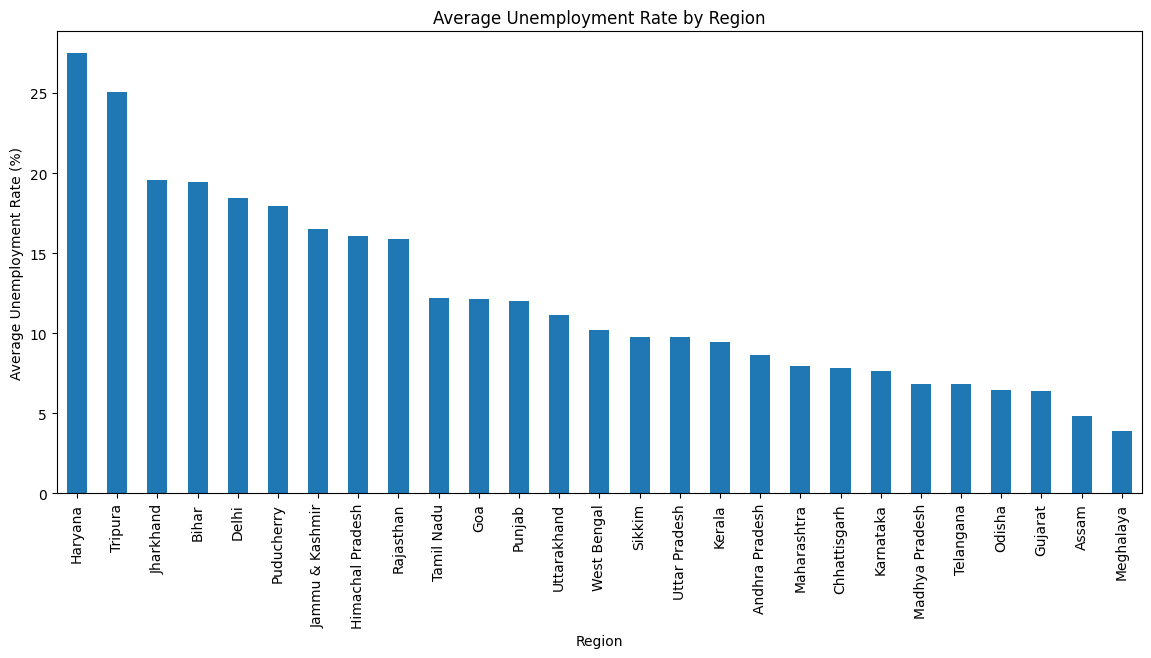

In [51]:
# Bar Chart

plt.figure(figsize=(14,6))
region_unemployment.plot(kind="bar")
plt.title("Average Unemployment Rate by Region")
plt.xlabel("Region")
plt.ylabel("Average Unemployment Rate (%)")
plt.xticks(rotation=90)
plt.show()

In [52]:
# Average Employment Region

employment = df.groupby("Region")["Estimated Employed"].mean().sort_values(ascending=False)
print(employment)

Region
Uttar Pradesh       5.552480e+07
Maharashtra         3.920476e+07
West Bengal         3.330516e+07
Bihar               2.360683e+07
Gujarat             2.273075e+07
Madhya Pradesh      2.231834e+07
Tamil Nadu          2.198790e+07
Karnataka           2.162402e+07
Rajasthan           1.973175e+07
Telangana           1.624408e+07
Andhra Pradesh      1.542548e+07
Odisha              1.272683e+07
Assam               1.081028e+07
Punjab              8.783034e+06
Jharkhand           8.770642e+06
Kerala              8.596795e+06
Chhattisgarh        8.421349e+06
Haryana             6.844059e+06
Delhi               4.632822e+06
Jammu & Kashmir     3.310032e+06
Uttarakhand         2.743275e+06
Himachal Pradesh    2.033885e+06
Tripura             1.397292e+06
Meghalaya           1.349815e+06
Goa                 4.423748e+05
Puducherry          3.652629e+05
Sikkim              2.345232e+05
Name: Estimated Employed, dtype: float64


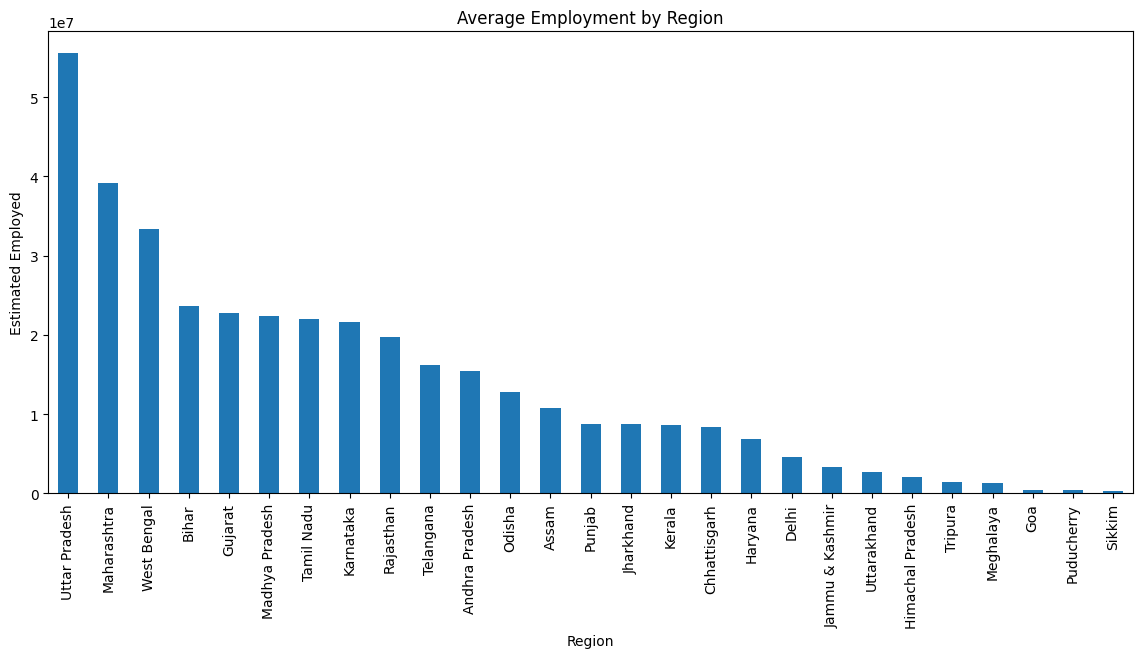

In [53]:
# Bar Chart

plt.figure(figsize=(14,6))
employment.plot(kind="bar")
plt.title("Average Employment by Region")
plt.xlabel("Region")
plt.ylabel("Estimated Employed")
plt.xticks(rotation=90)
plt.show()

In [54]:
monthly = df.groupby("Month")["Estimated Unemployment Rate (%)"].mean()
print(monthly)

Month
1      9.196538
2      9.266154
3     10.782593
4     22.236154
5     23.244444
6     10.911111
7      9.834444
8     10.313333
9      8.705926
10     8.026296
Name: Estimated Unemployment Rate (%), dtype: float64


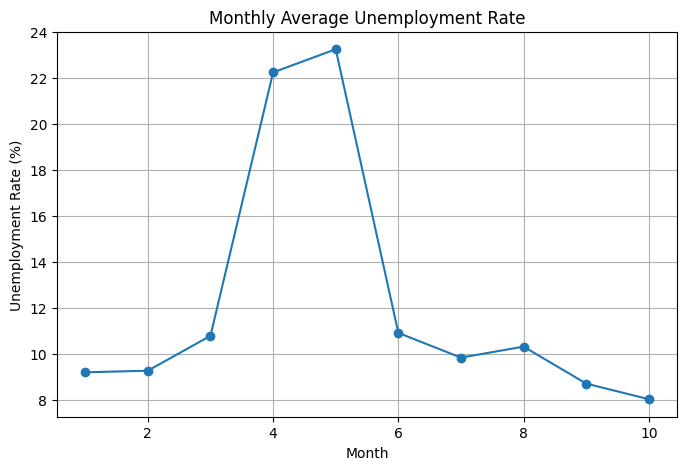

In [55]:
# Line Chart

plt.figure(figsize=(8,5))
plt.plot(monthly.index,monthly.values,marker='o')
plt.title("Monthly Average Unemployment Rate")
plt.xlabel("Month")
plt.ylabel("Unemployment Rate (%)")
plt.grid(True)
plt.show()

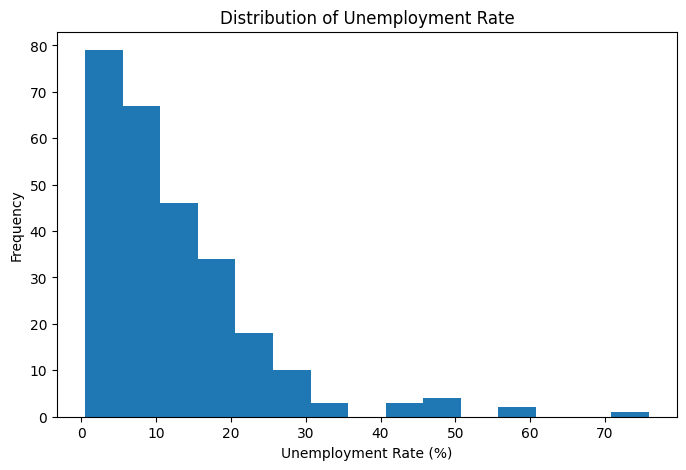

In [56]:
# Histogram

plt.figure(figsize=(8,5))
plt.hist(df["Estimated Unemployment Rate (%)"],bins=15)
plt.title("Distribution of Unemployment Rate")
plt.xlabel("Unemployment Rate (%)")
plt.ylabel("Frequency")
plt.show()

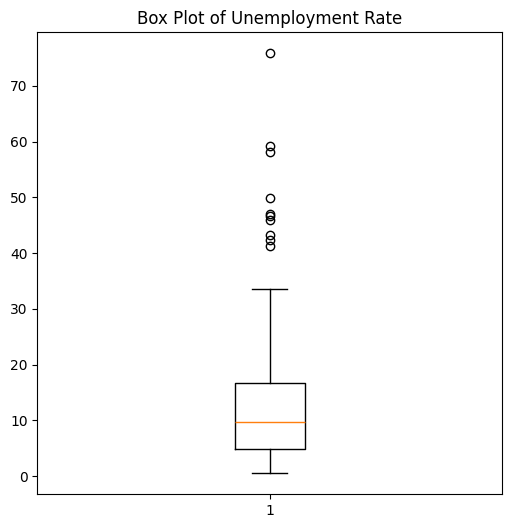

In [57]:
# Box Plot

plt.figure(figsize=(6,6))
plt.boxplot(df["Estimated Unemployment Rate (%)"])
plt.title("Box Plot of Unemployment Rate")
plt.show()

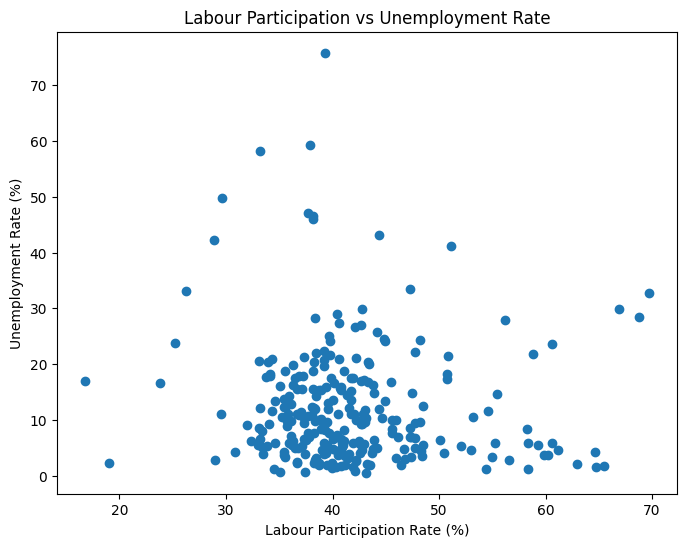

In [58]:
# Scatter Plot

plt.figure(figsize=(8,6))
plt.scatter(
    df["Estimated Labour Participation Rate (%)"],
    df["Estimated Unemployment Rate (%)"]
)
plt.title("Labour Participation vs Unemployment Rate")
plt.xlabel("Labour Participation Rate (%)")
plt.ylabel("Unemployment Rate (%)")
plt.show()

In [59]:
# Correlation Matrix

correlation = df[[
    "Estimated Unemployment Rate (%)",
    "Estimated Employed",
    "Estimated Labour Participation Rate (%)",
    "longitude",
    "latitude"
]].corr()
print(correlation)

                                         Estimated Unemployment Rate (%)  \
Estimated Unemployment Rate (%)                                 1.000000   
Estimated Employed                                             -0.245176   
Estimated Labour Participation Rate (%)                        -0.073540   
longitude                                                       0.149976   
latitude                                                       -0.023976   

                                         Estimated Employed  \
Estimated Unemployment Rate (%)                   -0.245176   
Estimated Employed                                 1.000000   
Estimated Labour Participation Rate (%)           -0.047948   
longitude                                         -0.113664   
latitude                                          -0.119321   

                                         Estimated Labour Participation Rate (%)  \
Estimated Unemployment Rate (%)                                        -0.073540

In [60]:
highest = df.groupby("Region")["Estimated Unemployment Rate (%)"].mean()
highest = highest.sort_values(ascending=False)
print(highest.head(10))

Region
Haryana             27.477000
Tripura             25.055000
Jharkhand           19.539000
Bihar               19.471000
Delhi               18.414000
Puducherry          17.942000
Jammu & Kashmir     16.477778
Himachal Pradesh    16.065000
Rajasthan           15.868000
Tamil Nadu          12.187000
Name: Estimated Unemployment Rate (%), dtype: float64


In [61]:
lowest = df.groupby("Region")["Estimated Unemployment Rate (%)"].mean()
lowest = lowest.sort_values()
print(lowest.head(10))

Region
Meghalaya         3.866
Assam             4.856
Gujarat           6.376
Odisha            6.462
Telangana         6.833
Madhya Pradesh    6.854
Karnataka         7.668
Chhattisgarh      7.819
Maharashtra       7.979
Andhra Pradesh    8.664
Name: Estimated Unemployment Rate (%), dtype: float64


In [62]:
highest_emp = df.groupby("Region")["Estimated Employed"].mean()
highest_emp = highest_emp.sort_values(ascending=False)
print(highest_emp.head(10))

Region
Uttar Pradesh     55524799.0
Maharashtra       39204758.2
West Bengal       33305164.3
Bihar             23606828.0
Gujarat           22730746.1
Madhya Pradesh    22318335.3
Tamil Nadu        21987898.1
Karnataka         21624017.6
Rajasthan         19731752.2
Telangana         16244082.5
Name: Estimated Employed, dtype: float64


In [63]:
covid = df[df["Year"] == 2020]
covid.head()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Region.1,longitude,latitude,Month,Year
0,Andhra Pradesh,2020-01-31,M,5.48,16635535,41.02,South,15.9129,79.74,1,2020
1,Andhra Pradesh,2020-02-29,M,5.83,16545652,40.90,South,15.9129,79.74,2,2020
2,Andhra Pradesh,2020-03-31,M,5.79,15881197,39.18,South,15.9129,79.74,3,2020
3,Andhra Pradesh,2020-04-30,M,20.51,11336911,33.10,South,15.9129,79.74,4,2020
4,Andhra Pradesh,2020-05-31,M,17.43,12988845,36.46,South,15.9129,79.74,5,2020


In [64]:
covid_month = covid.groupby("Month")["Estimated Unemployment Rate (%)"].mean()
print(covid_month)

Month
1      9.196538
2      9.266154
3     10.782593
4     22.236154
5     23.244444
6     10.911111
7      9.834444
8     10.313333
9      8.705926
10     8.026296
Name: Estimated Unemployment Rate (%), dtype: float64


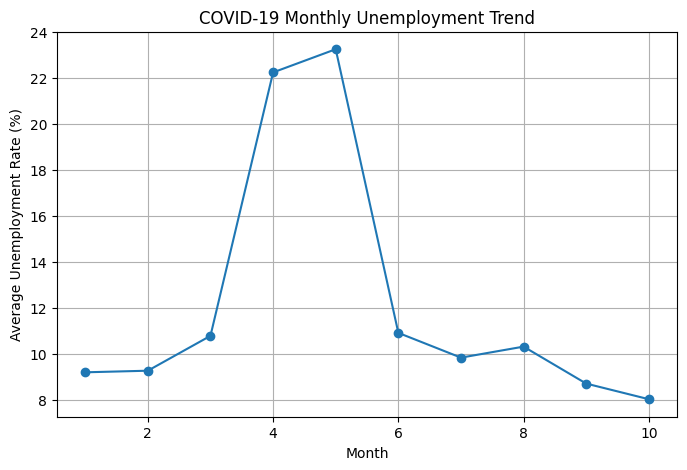

In [65]:
# Line graph

plt.figure(figsize=(8,5))
plt.plot(covid_month.index,covid_month.values,marker="o")
plt.title("COVID-19 Monthly Unemployment Trend")
plt.xlabel("Month")
plt.ylabel("Average Unemployment Rate (%)")
plt.grid(True)
plt.show()

In [66]:
top10 = df.sort_values(
    "Estimated Unemployment Rate (%)",
    ascending=False
)
top10.head(10)

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Region.1,longitude,latitude,Month,Year
172,Puducherry,2020-04-30,M,75.85,117542,39.30,South,11.9416,79.8083,4,2020
103,Jharkhand,2020-05-31,M,59.23,4145385,37.92,East,23.6102,85.2799,5,2020
173,Puducherry,2020-05-31,M,58.19,172308,33.19,South,11.9416,79.8083,5,2020
210,Tamil Nadu,2020-04-30,M,49.83,9719167,29.63,South,11.1271,78.6569,4,2020
102,Jharkhand,2020-04-30,M,47.09,5335262,37.69,East,23.6102,85.2799,4,2020
23,Bihar,2020-04-30,M,46.64,16046236,38.17,East,25.0961,85.3131,4,2020
24,Bihar,2020-05-31,M,45.96,16280203,38.16,East,25.0961,85.3131,5,2020
73,Haryana,2020-04-30,M,43.22,5647630,44.38,North,29.0588,76.0856,4,2020
44,Delhi,2020-05-31,M,42.27,2632404,28.91,North,28.7041,77.1025,5,2020
230,Tripura,2020-04-30,M,41.23,971514,51.16,Northeast,23.9408,91.9882,4,2020


In [67]:
lowest10 = df.sort_values(
    "Estimated Unemployment Rate (%)"
)
lowest10.head(10)

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Region.1,longitude,latitude,Month,Year
116,Karnataka,2020-08-31,M,0.50,24094289,43.13,South,15.3173,75.7139,8,2020
169,Puducherry,2020-01-31,M,0.58,457950,37.46,South,11.9416,79.8083,1,2020
15,Assam,2020-06-30,M,0.60,9095944,35.07,Northeast,26.2006,92.9376,6,2020
206,Sikkim,2020-10-31,M,0.88,242068,42.13,Northeast,27.5330,88.5122,10,2020
154,Meghalaya,2020-06-30,M,1.15,1350794,58.31,Northeast,25.4670,91.3662,6,2020
18,Assam,2020-09-30,M,1.19,14107641,54.38,Northeast,26.2006,92.9376,9,2020
171,Puducherry,2020-03-31,M,1.20,421028,34.49,South,11.9416,79.8083,3,2020
166,Odisha,2020-08-31,M,1.42,14154039,39.96,East,20.9517,85.0985,8,2020
207,Tamil Nadu,2020-01-31,M,1.57,26881641,41.96,South,11.1271,78.6569,1,2020
118,Karnataka,2020-10-31,M,1.58,22356390,40.30,South,15.3173,75.7139,10,2020


In [68]:
print("Maximum Unemployment Rate:")
print(df["Estimated Unemployment Rate (%)"].max())
print()
print("Minimum Unemployment Rate:")
print(df["Estimated Unemployment Rate (%)"].min())

print()
print("Average Unemployment Rate:")
print(df["Estimated Unemployment Rate (%)"].mean())

print()
print("Maximum Employment:")
print(df["Estimated Employed"].max())

print()
print("Minimum Employment:")
print(df["Estimated Employed"].min())

Maximum Unemployment Rate:
75.85

Minimum Unemployment Rate:
0.5

Average Unemployment Rate:
12.236928838951311

Maximum Employment:
59433759

Minimum Employment:
117542


In [69]:
## Feature Engineering and Machine Learning

In [70]:
print(df.columns)

Index(['Region', 'Date', 'Frequency', 'Estimated Unemployment Rate (%)',
       'Estimated Employed', 'Estimated Labour Participation Rate (%)',
       'Region.1', 'longitude', 'latitude', 'Month', 'Year'],
      dtype='object')


In [71]:
from sklearn.preprocessing import LabelEncoder

le_region = LabelEncoder()
le_frequency = LabelEncoder()
le_region1 = LabelEncoder()

df["Region"] = le_region.fit_transform(df["Region"])
df["Frequency"] = le_frequency.fit_transform(df["Frequency"])
df["Region.1"] = le_region1.fit_transform(df["Region.1"])

In [72]:
df.head()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Region.1,longitude,latitude,Month,Year
0,0,2020-01-31,0,5.48,16635535,41.02,3,15.9129,79.74,1,2020
1,0,2020-02-29,0,5.83,16545652,40.90,3,15.9129,79.74,2,2020
2,0,2020-03-31,0,5.79,15881197,39.18,3,15.9129,79.74,3,2020
3,0,2020-04-30,0,20.51,11336911,33.10,3,15.9129,79.74,4,2020
4,0,2020-05-31,0,17.43,12988845,36.46,3,15.9129,79.74,5,2020


In [73]:
X = df[[
    "Region",
    "Frequency",
    "Estimated Employed",
    "Estimated Labour Participation Rate (%)",
    "longitude",
    "latitude",
    "Month",
    "Year"
]]
y = df["Estimated Unemployment Rate (%)"]

In [74]:
# Display Features
print(X.head())

   Region  Frequency  Estimated Employed  \
0       0          0            16635535   
1       0          0            16545652   
2       0          0            15881197   
3       0          0            11336911   
4       0          0            12988845   

   Estimated Labour Participation Rate (%)  longitude  latitude  Month  Year  
0                                    41.02    15.9129     79.74      1  2020  
1                                    40.90    15.9129     79.74      2  2020  
2                                    39.18    15.9129     79.74      3  2020  
3                                    33.10    15.9129     79.74      4  2020  
4                                    36.46    15.9129     79.74      5  2020  


In [76]:
#Display Target
print(y.head())

0     5.48
1     5.83
2     5.79
3    20.51
4    17.43
Name: Estimated Unemployment Rate (%), dtype: float64


In [77]:
# Split Dataset
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [78]:
print("Training Features:", X_train.shape)
print("Testing Features:", X_test.shape)
print("Training Labels:", y_train.shape)
print("Testing Labels:", y_test.shape)

Training Features: (213, 8)
Testing Features: (54, 8)
Training Labels: (213,)
Testing Labels: (54,)


In [79]:
from sklearn.linear_model import LinearRegression

In [80]:
model = LinearRegression()

In [81]:
model.fit(X_train, y_train)

LinearRegression()

In [82]:
print("Intercept:", model.intercept_)
print("\nCoefficients:")
for feature, coef in zip(X.columns, model.coef_):
    print(f"{feature}: {coef}")

Intercept: 18.236767847209176

Coefficients:
Region: 0.10163789340072513
Frequency: 1.6464862146510427e-11
Estimated Employed: -2.2511844156633957e-07
Estimated Labour Participation Rate (%): -0.15721276148913307
longitude: 0.14652091162090403
latitude: 0.023710064668744882
Month: -0.48626268880217816
Year: 0.0


In [83]:
y_pred = model.predict(X_test)

In [84]:
results = X_test.copy()
results["Actual"] = y_test.values
results["Predicted"] = y_pred
results.head(10)

,Region,Frequency,Estimated Employed,Estimated Labour Participation Rate (%),longitude,latitude,Month,Year,Actual,Predicted
84,8,0,1897639,42.70,31.1048,77.1734,5,2020,26.95,15.865669
46,4,0,4291053,33.97,28.7041,77.1025,7,2020,20.30,14.966824
183,18,0,6872938,38.39,31.1471,75.3412,5,2020,28.33,16.402360
236,23,0,1576529,54.58,23.9408,91.9882,10,2020,11.57,12.465108
177,17,0,411717,36.84,11.9416,79.8083,9,2020,10.90,13.345799
222,22,0,15108910,53.22,18.1124,79.0193,6,2020,10.55,10.314466
60,6,0,24126346,48.49,22.2587,71.1924,1,2020,5.54,10.255142
260,26,0,26938836,39.90,22.9868,87.8550,4,2020,17.41,12.048179
195,19,0,19932393,40.80,27.0238,74.2179,7,2020,15.81,11.581882
117,11,0,20127176,36.66,15.3173,75.7139,9,2020,2.41,8.723488


In [85]:
## Model Evalution, Visualization & Saving

In [ ]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
import numpy as np

In [86]:
mae = mean_absolute_error(y_test, y_pred)
print("Mean Absolute Error (MAE):", mae)

Mean Absolute Error (MAE): 6.9842663680678525


In [87]:
mse = mean_squared_error(y_test, y_pred)
print("Mean Squared Error (MSE):", mse)

Mean Squared Error (MSE): 87.84130987050031


In [88]:
rmse = np.sqrt(mse)
print("Root Mean Squared Error (RMSE):", rmse)

Root Mean Squared Error (RMSE): 9.372369490715798


In [89]:
r2 = r2_score(y_test, y_pred)
print("R² Score:", r2)

R² Score: 0.0662632226669182


In [90]:
print("="*40)

print("MODEL EVALUATION")

print("="*40)

print(f"MAE  : {mae:.2f}")

print(f"MSE  : {mse:.2f}")

print(f"RMSE : {rmse:.2f}")

print(f"R² Score : {r2:.4f}")

MODEL EVALUATION
MAE  : 6.98
MSE  : 87.84
RMSE : 9.37
R² Score : 0.0663


In [91]:
comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})
comparison.head(15)

,Actual,Predicted
0,26.95,15.865669
1,20.30,14.966824
2,28.33,16.402360
3,11.57,12.465108
4,10.90,13.345799
5,10.55,10.314466
6,5.54,10.255142
7,17.41,12.048179
8,15.81,11.581882
9,2.41,8.723488


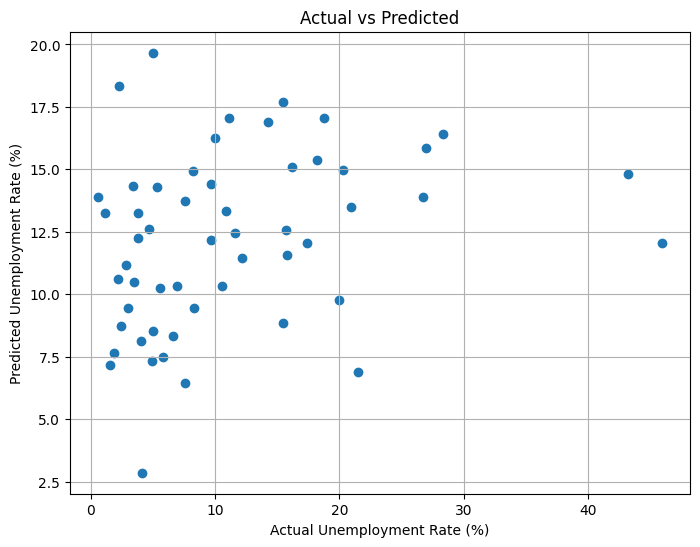

In [92]:
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Unemployment Rate (%)")
plt.ylabel("Predicted Unemployment Rate (%)")
plt.title("Actual vs Predicted")
plt.grid(True)
plt.show()

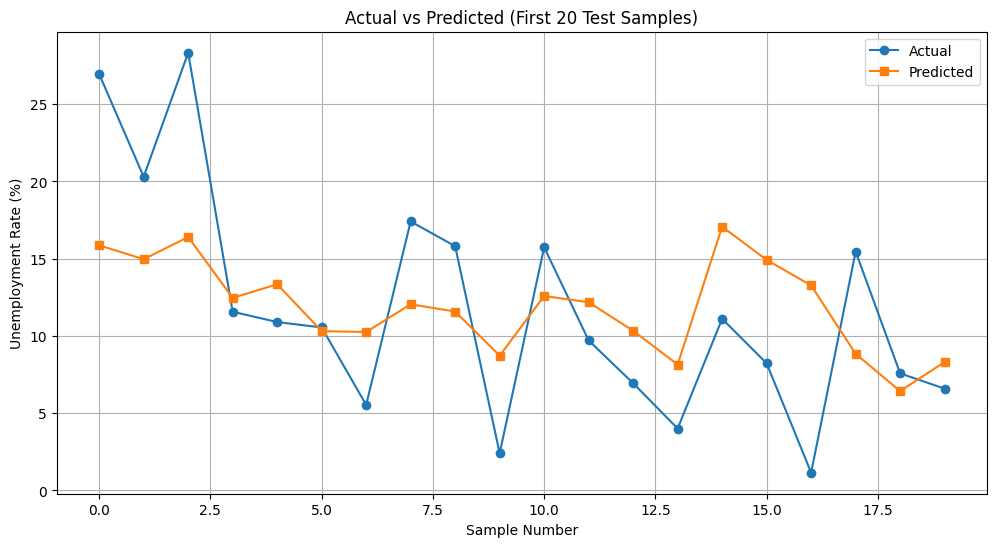

In [93]:
plt.figure(figsize=(12,6))
plt.plot(
    comparison["Actual"].values[:20],
    label="Actual",
    marker="o"
)
plt.plot(
    comparison["Predicted"].values[:20],
    label="Predicted",
    marker="s"
)
plt.title("Actual vs Predicted (First 20 Test Samples)")
plt.xlabel("Sample Number")
plt.ylabel("Unemployment Rate (%)")
plt.legend()
plt.grid(True)
plt.show()

In [94]:
residuals = y_test - y_pred
print(residuals.head())

84     11.084331
46      5.333176
183    11.927640
236    -0.895108
177    -2.445799
Name: Estimated Unemployment Rate (%), dtype: float64


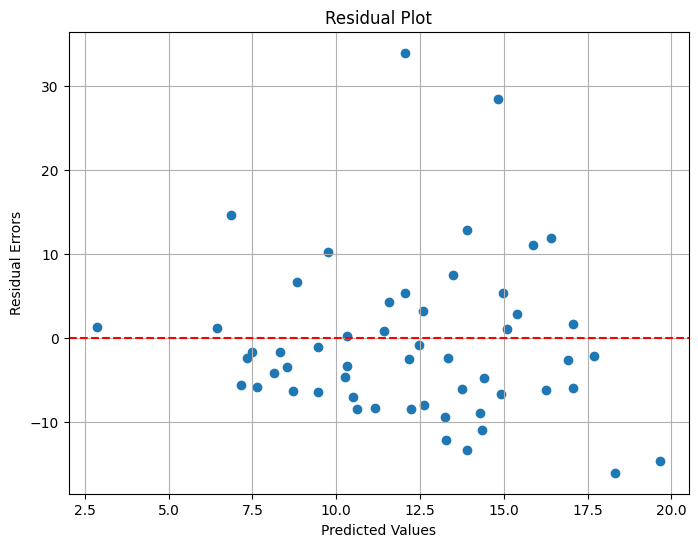

In [95]:
plt.figure(figsize=(8,6))
plt.scatter(y_pred, residuals)
plt.axhline(y=0,
            color="red",
            linestyle="--")
plt.xlabel("Predicted Values")
plt.ylabel("Residual Errors")
plt.title("Residual Plot")
plt.grid(True)
plt.show()

In [96]:
import joblib
joblib.dump(model, "Unemployment_Prediction_Model.pkl")
print("Model Saved Successfully!")

Model Saved Successfully!


In [97]:
df.to_csv("Clean_Unemployment_Data.csv", index=False)
print("Clean Dataset Saved Successfully!")

Clean Dataset Saved Successfully!


In [98]:
from google.colab import files
files.download("Unemployment_Prediction_Model.pkl")
files.download("Clean_Unemployment_Data.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [99]:
sample = [[
    5,          # Region (encoded)
    0,          # Frequency (encoded)
    5000000,    # Estimated Employed
    42.5,       # Labour Participation Rate
    76.26,      # Longitude
    10.85,      # Latitude
    6,          # Month
    2020        # Year
]]
prediction = model.predict(sample)
print("Predicted Unemployment Rate:", prediction[0])

Predicted Unemployment Rate: 19.451185532145903
